# SVM vs VQC. Comparativa

Este notebook carga los resultados precomputados de:
- `../classical/svm_results.json`
- `../quantum/vqc_results.json`

y genera todos los gráficos de comparación y las tablas de resumen.

No se entrena ningún modelo aquí. Se puede re-ejecutar libremente sin tocar los notebooks de entrenamiento.

Si los resultados de 4 características están disponibles (`*_4f.json`), establecer `COMPARE_4F = True`  
para incluir la sección de comparación 2 características vs 4 características.

## Imports

In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Configuración

In [ ]:
COMPARE_4F = True   # set True when 4-feature results are available

SVM_FILE    = "../classical/svm_results.json"
VQC_FILE    = "../quantum/vqc_results.json"
SVM_4F_FILE = "../classical/svm_results_4f.json"
VQC_4F_FILE = "../quantum/vqc_results_4f.json"

for f in [SVM_FILE, VQC_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Missing results file: {f}\n"
            "Run svm.ipynb and vqc.ipynb first."
        )

if COMPARE_4F:
    for f in [SVM_4F_FILE, VQC_4F_FILE]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing 4-feature results file: {f}")

print("Results files found — ready to compare.")

Results files found — ready to compare.


## Carga de resultados

In [23]:
with open(SVM_FILE) as f:
    svm = json.load(f)

with open(VQC_FILE) as f:
    vqc = json.load(f)

if COMPARE_4F:
    with open(SVM_4F_FILE) as f:
        svm4 = json.load(f)
    with open(VQC_4F_FILE) as f:
        vqc4 = json.load(f)

print("SVM results loaded:")
print(f"  Test accuracy : {svm['accuracy_test']:.4f}")
print(f"  Train time    : {svm['train_time_s']:.4f} s")
print()
print("VQC results loaded:")
print(f"  Test accuracy (sim)  : {vqc['accuracy_test_sim']:.4f}")
if vqc.get('real_hw_run'):
    print(f"  Test accuracy (real) : {vqc['accuracy_test_real']:.4f}")
print(f"  Train time (sim)     : {vqc['train_time_sim_s']:.2f} s")

SVM results loaded:
  Test accuracy : 0.8500
  Train time    : 0.0032 s

VQC results loaded:
  Test accuracy (sim)  : 0.7000
  Test accuracy (real) : 0.7000
  Train time (sim)     : 271.16 s


## Gráfica 1. Comparativa de precisión

Diagrama de barras comparando la precisión de test del SVM vs el VQC (simulador y hardware real si está disponible).  
También muestra la media ± desviación estándar de la validación cruzada del SVM.

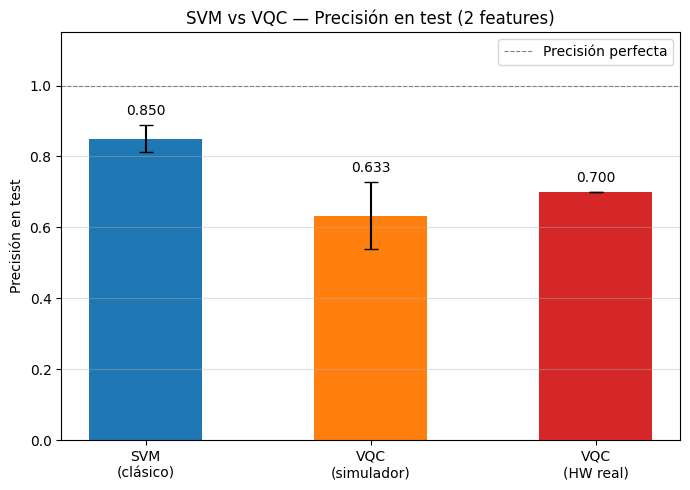

Barra de error VQC: ±0.0943 sobre 3 ejecuciones con semillas [42, 123, 7]


In [24]:
labels  = ["SVM\n(clásico)", "VQC\n(simulador)"]
values  = [svm["accuracy_test"], vqc.get("accuracy_test_mean", vqc["accuracy_test_sim"])]
colors  = ["tab:blue", "tab:orange"]
yerr    = [svm["cv_std"], vqc.get("accuracy_test_std", 0)]

if vqc.get("real_hw_run") and vqc.get("accuracy_test_real") is not None:
    labels.append("VQC\n(HW real)")
    values.append(vqc["accuracy_test_real"])
    colors.append("tab:red")
    yerr.append(0)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, values, color=colors, width=0.5,
              yerr=yerr, capsize=5, error_kw={"elinewidth": 1.5})

# Place label above the error bar cap so it never overlaps the error bar line
for bar, val, err in zip(bars, values, yerr):
    ax.text(bar.get_x() + bar.get_width() / 2, val + err + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Precisión en test")
ax.set_title(f"SVM vs VQC — Precisión en test ({svm['n_features']} características)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Precisión perfecta")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_accuracy.png", dpi=150)
plt.show()

if vqc.get("accuracy_test_std", 0) > 0:
    print(f"Barra de error VQC: ±{vqc['accuracy_test_std']:.4f} sobre {vqc['n_runs']} ejecuciones con semillas {vqc['init_seeds']}")

## Gráfica 2. Tiempo de entrenamiento

La diferencia en tiempo de entrenamiento es la brecha práctica más llamativa entre SVM y VQC.  
Nótese la escala logarítmica, la simulación del VQC es órdenes de magnitud más lenta para este tamaño de problema.

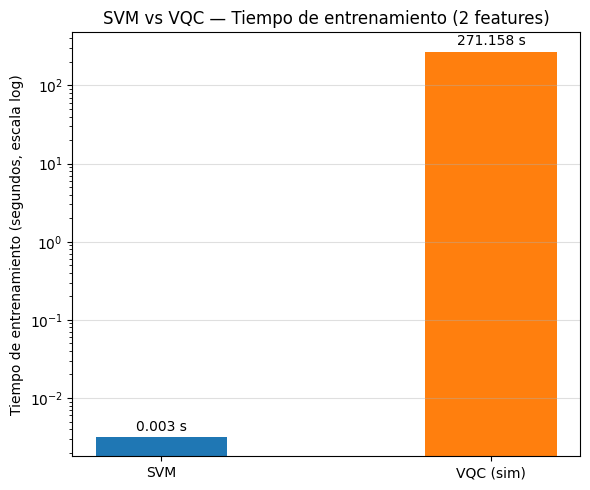

In [25]:
t_labels = ["SVM", "VQC (sim)"]
t_values = [svm["train_time_s"], vqc["train_time_sim_s"]]
t_colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(t_labels, t_values, color=t_colors, width=0.4)
for bar, val in zip(bars, t_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.1,
            f"{val:.3f} s", ha="center", va="bottom", fontsize=10)

ax.set_yscale("log")
ax.set_ylabel("Tiempo de entrenamiento (segundos, escala log)")
ax.set_title(f"SVM vs VQC — Tiempo de entrenamiento ({svm['n_features']} características)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot2_training_time.png", dpi=150)
plt.show()

## Gráfica 3. Curva de pérdida del VQC

Muestra cómo converge el VQC durante el entrenamiento. Útil para valorar si más iteraciones  
mejorarían el resultado (si la curva no se ha aplanado, aumentar `MAX_ITER` en `vqc.ipynb`).

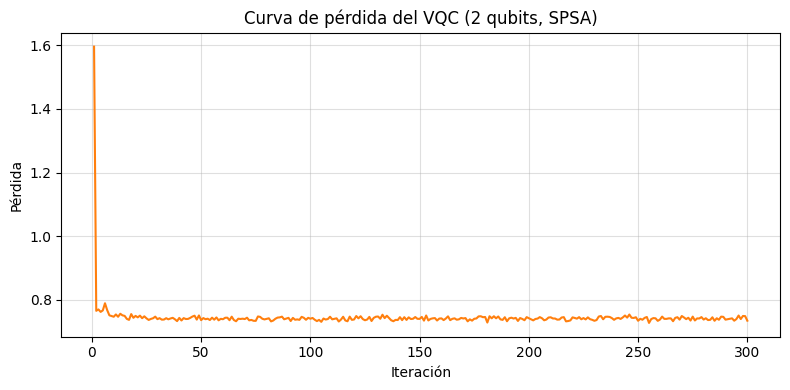

In [26]:
loss = vqc["loss_history"]

if loss:
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(loss) + 1), loss, color="tab:orange")
    plt.xlabel("Iteración")
    plt.ylabel("Pérdida")
    plt.title(f"Curva de pérdida del VQC ({vqc['n_qubits']} qubits, {vqc['optimizer']})")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("plot3_vqc_loss.png", dpi=150)
    plt.show()
else:
    print("El historial de pérdida está vacío — se omite la curva de pérdida.")
    print("(Ocurre cuando el VQC se ejecutó con un optimizador sin gradiente que no registra la pérdida por iteración.)")

## Gráfica 4. Matrices de confusión comparadas

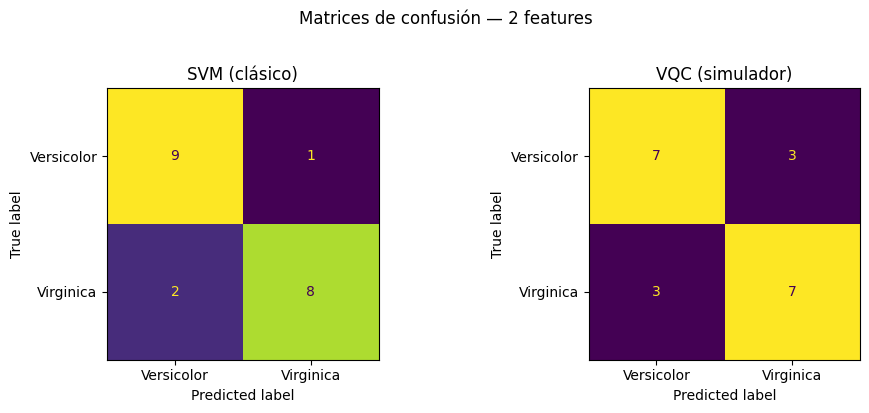

In [27]:
cm_svm = confusion_matrix(svm["y_test"], svm["y_pred_test"])
cm_vqc = confusion_matrix(vqc["y_test"], vqc["y_pred_test_sim"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes,
                          [cm_svm, cm_vqc],
                          ["SVM (clásico)", "VQC (simulador)"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Versicolor", "Virginica"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f"Matrices de confusión — {svm['n_features']} features", y=1.02)
plt.tight_layout()
plt.savefig("plot4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfica 5. Compromiso precisión / tiempo de entrenamiento

Métrica única que combina ambos ejes: ¿cuánta precisión se obtiene por unidad de tiempo de entrenamiento?  
Un valor más alto es mejor. Útil para resumir en una sola figura el compromiso cuántico vs clásico.

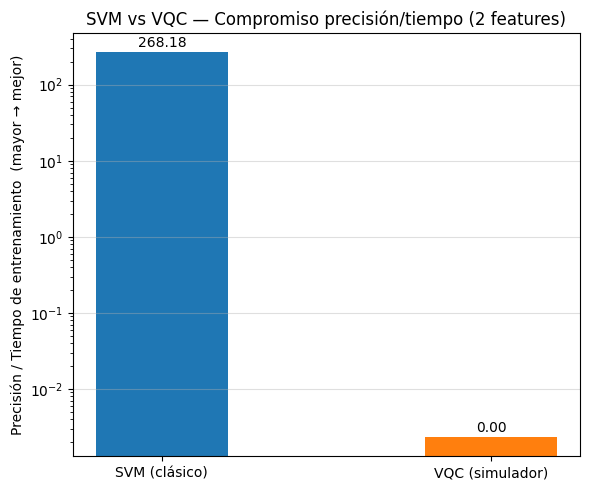

Ratio SVM: 268.18  (acc=0.850, tiempo=0.0032s)
Ratio VQC: 0.0023  (acc=0.633, tiempo=271.16s)


In [28]:
ratio_svm = svm["accuracy_test"]  / svm["train_time_s"]
ratio_vqc = vqc.get("accuracy_test_mean", vqc["accuracy_test_sim"]) / vqc["train_time_sim_s"]

r_labels = ["SVM (clásico)", "VQC (simulador)"]
r_values = [ratio_svm, ratio_vqc]
r_colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(r_labels, r_values, color=r_colors, width=0.4)
for bar, val in zip(bars, r_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Precisión / Tiempo de entrenamiento  (mayor → mejor)")
ax.set_title(f"SVM vs VQC — Compromiso precisión/tiempo ({svm['n_features']} características)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot5_ratio.png", dpi=150)
plt.show()

print(f"Ratio SVM: {ratio_svm:.2f}  (acc={svm['accuracy_test']:.3f}, tiempo={svm['train_time_s']:.4f}s)")
print(f"Ratio VQC: {ratio_vqc:.4f}  (acc={vqc.get('accuracy_test_mean', vqc['accuracy_test_sim']):.3f}, tiempo={vqc['train_time_sim_s']:.2f}s)")

## Gráfica 6. Comparativa 2 características vs 4 características (opcional)

Solo se muestra cuando `COMPARE_4F = True` y existen ambos archivos de resultados con 4 features.

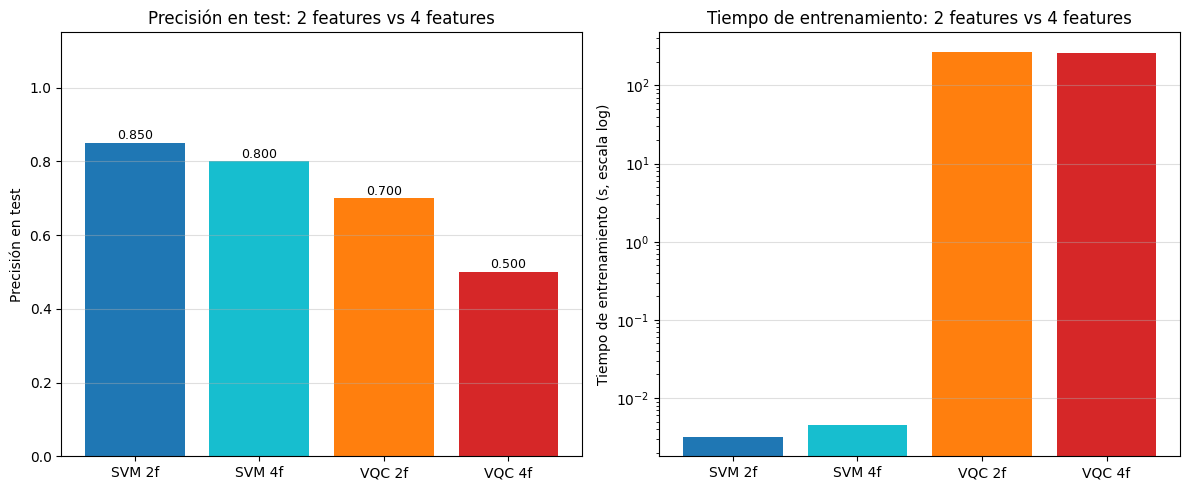

In [29]:
if COMPARE_4F:
    experiments = [
        ("SVM 2f",  svm["accuracy_test"],     svm["train_time_s"],     "tab:blue"),
        ("SVM 4f",  svm4["accuracy_test"],    svm4["train_time_s"],    "tab:cyan"),
        ("VQC 2f",  vqc["accuracy_test_sim"],  vqc["train_time_sim_s"],  "tab:orange"),
        ("VQC 4f",  vqc4["accuracy_test_sim"], vqc4["train_time_sim_s"], "tab:red"),
    ]

    names   = [e[0] for e in experiments]
    accs    = [e[1] for e in experiments]
    times   = [e[2] for e in experiments]
    colors  = [e[3] for e in experiments]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, accs, color=colors)
    for i, (name, val) in enumerate(zip(names, accs)):
        axes[0].text(i, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_ylabel("Precisión en test")
    axes[0].set_title("Precisión en test: 2 features vs 4 features")
    axes[0].grid(axis="y", alpha=0.4)

    axes[1].bar(names, times, color=colors)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Tiempo de entrenamiento (s, escala log)")
    axes[1].set_title("Tiempo de entrenamiento: 2 features vs 4 features")
    axes[1].grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.savefig("plot6_2f_vs_4f.png", dpi=150)
    plt.show()
else:
    print("COMPARE_4F es False — se omite la comparativa 2f vs 4f.")

## Tabla resumen

Impresa en pantalla y guardada en `comparison_summary.json`.

In [30]:
summary = {
    "n_features"              : svm["n_features"],
    "n_train"                 : svm["n_train"],
    "n_test"                  : svm["n_test"],
    "svm_accuracy_test"       : svm["accuracy_test"],
    "svm_cv_mean"             : svm["cv_mean"],
    "svm_cv_std"              : svm["cv_std"],
    "svm_train_time_s"        : svm["train_time_s"],
    "svm_n_support_vectors"   : svm["n_support_vectors"],
    "vqc_accuracy_test_sim"   : vqc["accuracy_test_sim"],
    "vqc_accuracy_test_mean"  : vqc.get("accuracy_test_mean"),
    "vqc_accuracy_test_std"   : vqc.get("accuracy_test_std"),
    "vqc_n_runs"              : vqc.get("n_runs"),
    "vqc_accuracy_test_real"  : vqc.get("accuracy_test_real"),
    "vqc_train_time_sim_s"    : vqc["train_time_sim_s"],
    "vqc_n_qubits"            : vqc["n_qubits"],
    "vqc_n_parameters"        : vqc["n_parameters"],
    "vqc_optimizer"           : vqc["optimizer"],
    "vqc_max_iter"            : vqc["max_iter"],
    "vqc_final_loss"          : vqc["loss_history"][-1] if vqc["loss_history"] else None,
    "vqc_real_hw_run"         : vqc.get("real_hw_run", False),
    "vqc_backend"             : vqc.get("backend_name"),
    "ratio_svm"               : svm["accuracy_test"] / svm["train_time_s"],
    "ratio_vqc_sim"           : vqc.get("accuracy_test_mean", vqc["accuracy_test_sim"]) / vqc["train_time_sim_s"],
}

if COMPARE_4F:
    summary["svm_4f_accuracy_test"]     = svm4["accuracy_test"]
    summary["svm_4f_train_time_s"]      = svm4["train_time_s"]
    summary["vqc_4f_accuracy_test_sim"] = vqc4["accuracy_test_sim"]
    summary["vqc_4f_train_time_sim_s"]  = vqc4["train_time_sim_s"]
    summary["vqc_4f_n_parameters"]      = vqc4["n_parameters"]

with open("comparison_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

col_w = 30
vqc_acc_str = (f"{vqc['accuracy_test_mean']:.4f} ± {vqc['accuracy_test_std']:.4f}"
               if vqc.get("accuracy_test_std") is not None else f"{vqc['accuracy_test_sim']:.4f}")

print(f"{'Metric':<{col_w}} {'SVM':>18} {'VQC (sim)':>22} {'VQC (real)':>12}")
print("-" * (col_w + 56))
rows = [
    ("Test accuracy",
     f"{svm['accuracy_test']:.4f}",
     vqc_acc_str,
     f"{vqc['accuracy_test_real']:.4f}" if vqc.get('accuracy_test_real') else "N/A"),
    ("Train accuracy",
     f"{svm['accuracy_train']:.4f}",
     f"{vqc['accuracy_train_sim']:.4f}",
     "N/A"),
    ("CV / multi-seed",
     f"{svm['cv_mean']:.4f} ± {svm['cv_std']:.4f}",
     vqc_acc_str,
     "N/A"),
    ("Train time (s)",
     f"{svm['train_time_s']:.4f}",
     f"{vqc['train_time_sim_s']:.2f}",
     "N/A"),
    ("Accuracy/time ratio",
     f"{svm['accuracy_test']/svm['train_time_s']:.2f}",
     f"{vqc.get('accuracy_test_mean',vqc['accuracy_test_sim'])/vqc['train_time_sim_s']:.4f}",
     "N/A"),
    ("Model params",
     f"{svm['n_support_vectors']} SVs",
     f"{vqc['n_parameters']} params",
     "—"),
]
for label, sv, vq, vr in rows:
    print(f"{label:<{col_w}} {sv:>18} {vq:>22} {vr:>12}")

print()
print("Summary saved to comparison_summary.json")


Metric                                        SVM              VQC (sim)   VQC (real)
--------------------------------------------------------------------------------------
Test accuracy                              0.8500        0.6333 ± 0.0943       0.7000
Train accuracy                             0.9750                 0.7500          N/A
CV / multi-seed                   0.9400 ± 0.0374        0.6333 ± 0.0943          N/A
Train time (s)                             0.0032                 271.16          N/A
Accuracy/time ratio                        268.18                 0.0023          N/A
Model params                               17 SVs               8 params            —

Summary saved to comparison_summary.json
